### Gradient with sigmoid

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
csv_path = '/content/drive/MyDrive/Assignments/Deep Learning/deep_learning_assignment_1/Iris.csv'
img_path = '/content/drive/MyDrive/Assignments/Deep Learning/deep_learning_assignment_1/monarch_in.jpg'

Epoch  0  loss 1.1117
Epoch 10  loss 1.1007
Epoch 20  loss 1.0981
Epoch 30  loss 1.0968
Epoch 40  loss 1.0764


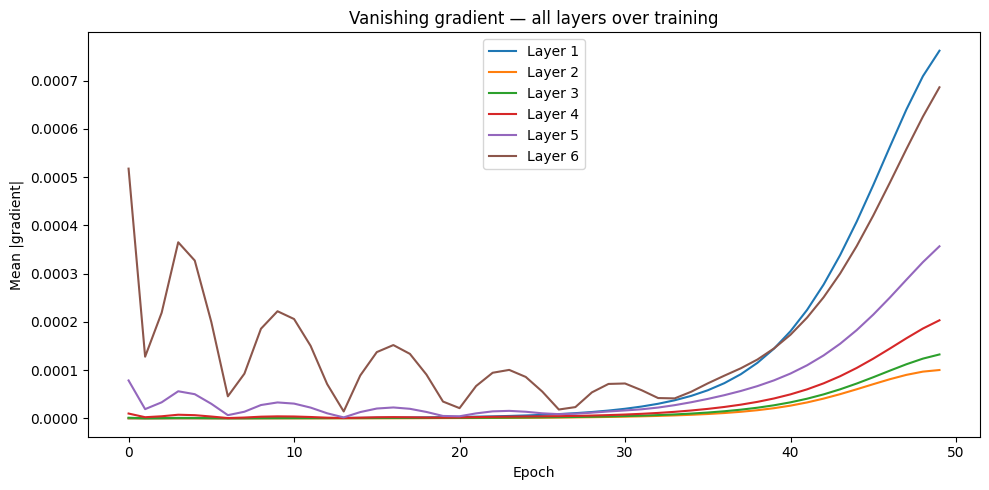

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Data ──────────────────────────────────────────────────────────────────────
df   = pd.read_csv(csv_path)
X    = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y    = LabelEncoder().fit_transform(df["Species"].values)
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)

# ── Model ─────────────────────────────────────────────────────────────────────
# Sigmoid is chosen deliberately — its gradient is always ≤ 0.25.
# During backprop each layer multiplies the incoming gradient by its local
# derivative.  With 6 layers: 0.25^6 ≈ 0.000244 — nearly zero by layer 1.
class DeepNet(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 128, 128, 128, 128, 128, 128]   # 6 hidden layers
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out = nn.Linear(128, 3)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.sigmoid(layer(x))   # ← the problem lives here
        return self.out(x)

model     = DeepNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Train & collect gradients ─────────────────────────────────────────────────
# After loss.backward() each weight tensor holds .grad — the average magnitude
# tells us how strongly that layer is being updated.  A near-zero gradient
# means the layer's weights barely move: it stops learning entirely.
history = [[] for _ in model.hidden]

for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(model(X_tr), y_tr)
    loss.backward()

    for i, layer in enumerate(model.hidden):
        history[i].append(layer.weight.grad.abs().mean().item())

    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}  loss {loss.item():.4f}")

# ── Plot 1: gradients over time ───────────────────────────────────────────────
# Early layers (1, 2) will be almost flat near zero — they receive an
# exponentially shrunken signal compared to the layers near the output.
plt.figure(figsize=(10, 5))
for i, h in enumerate(history):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing gradient — all layers over training")
plt.legend(); plt.tight_layout(); plt.show()


## Gradients with relu

Epoch  0  loss 1.0992
Epoch 10  loss 0.9512
Epoch 20  loss 0.4055
Epoch 30  loss 0.0801
Epoch 40  loss 0.0476


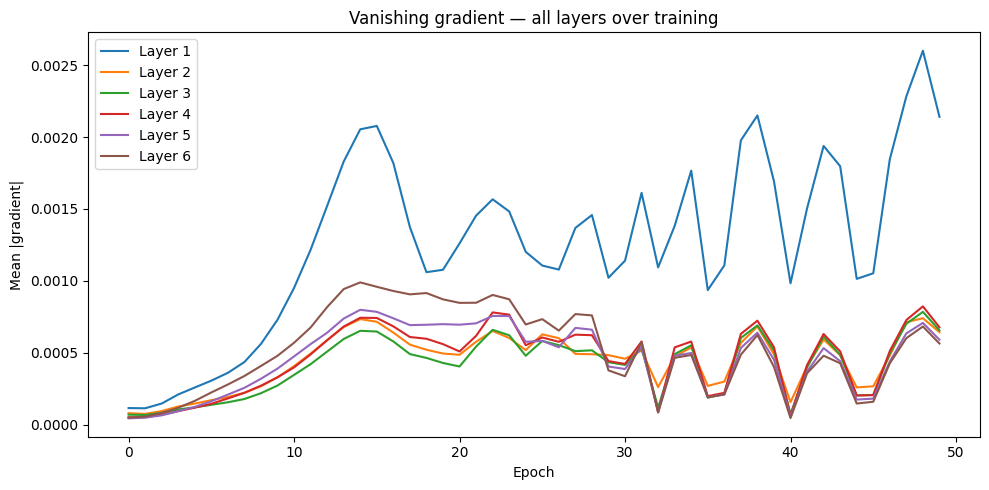

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Data ──────────────────────────────────────────────────────────────────────
df   = pd.read_csv(csv_path)
X    = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y    = LabelEncoder().fit_transform(df["Species"].values)
X_tr, _, y_tr, _ = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)

# ── Model ─────────────────────────────────────────────────────────────────────
# Sigmoid is chosen deliberately — its gradient is always ≤ 0.25.
# During backprop each layer multiplies the incoming gradient by its local
# derivative.  With 6 layers: 0.25^6 ≈ 0.000244 — nearly zero by layer 1.
class DeepNet(nn.Module):
    def __init__(self):
        super().__init__()
        sizes = [4, 128, 128, 128, 128, 128, 128]   # 6 hidden layers
        self.hidden = nn.ModuleList(
            [nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        self.out = nn.Linear(128, 3)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.relu(layer(x))   # ← ReLU gradient is 1 (when x>0), so no compounding shrinkage
        return self.out(x)

model     = DeepNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── Train & collect gradients ─────────────────────────────────────────────────
# After loss.backward() each weight tensor holds .grad — the average magnitude
# tells us how strongly that layer is being updated.  A near-zero gradient
# means the layer's weights barely move: it stops learning entirely.
history = [[] for _ in model.hidden]

for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(model(X_tr), y_tr)
    loss.backward()

    for i, layer in enumerate(model.hidden):
        history[i].append(layer.weight.grad.abs().mean().item())

    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d}  loss {loss.item():.4f}")

# ── Plot 1: gradients over time ───────────────────────────────────────────────
# Early layers (1, 2) will be almost flat near zero — they receive an
# exponentially shrunken signal compared to the layers near the output.
plt.figure(figsize=(10, 5))
for i, h in enumerate(history):
    plt.plot(h, label=f"Layer {i+1}")
plt.xlabel("Epoch"); plt.ylabel("Mean |gradient|")
plt.title("Vanishing gradient — all layers over training")
plt.legend(); plt.tight_layout(); plt.show()


Numpy MSE backprop

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Data ──────────────────────────────────────────────────────────────────────
# California Housing: 20,640 samples, 8 features → predict median house price.
# This is a real regression target (continuous $), so MSE is now the RIGHT loss.
data  = fetch_california_housing()
X, y  = data.data, data.target.reshape(-1, 1)   # y shape: (N,1) not (N,)

X = StandardScaler().fit_transform(X)            # zero mean, unit variance per feature
y = (y - y.mean()) / y.std()                     # normalise target too — keeps gradients small

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Helpers ───────────────────────────────────────────────────────────────────
relu  = lambda z: np.maximum(0, z)
relu_ = lambda z: (z > 0).astype(float)          # derivative: 1 where active, 0 where dead

# MSE and its derivative w.r.t predictions
mse   = lambda p, t: np.mean((p - t) ** 2)
dmse  = lambda p, t: 2 * (p - t) / len(p)        # dL/d(y_pred) — feeds into backprop

# ── Architecture ──────────────────────────────────────────────────────────────
# Input(8) → Hidden(64, ReLU) → Output(1, linear)
# Linear output — no activation — because we're predicting a real number, not a probability.
# Sigmoid/tanh on output would squash predictions into (0,1) and destroy range.
np.random.seed(42)
H = 64
W1 = np.random.randn(8,  H) * np.sqrt(2/8)      # He init: accounts for ReLU killing ~50% of neurons
b1 = np.zeros((1, H))
W2 = np.random.randn(H,  1) * np.sqrt(2/H)
b2 = np.zeros((1, 1))

# ── Training ──────────────────────────────────────────────────────────────────
lr, epochs = 0.01, 200

for epoch in range(epochs):

    # Forward: two affine transforms, one ReLU, one linear output
    z1   = X_tr @ W1 + b1                        # (N, H)
    a1   = relu(z1)                               # neurons with z1<0 output 0 — they're "dead" this pass
    pred = a1 @ W2 + b2                           # (N, 1) — raw real-valued prediction

    loss = mse(pred, y_tr)

    # Backward: chain rule from loss → W2 → W1
    # Each dW is: (upstream gradient) × (local gradient)
    dL   = dmse(pred, y_tr)                       # dL/d(pred): how loss changes with prediction
    dW2  = a1.T @ dL                              # dL/dW2: how prediction changes with W2
    db2  = dL.sum(axis=0, keepdims=True)

    da1  = dL @ W2.T                              # propagate error back through W2
    dz1  = da1 * relu_(z1)                        # ReLU gate: zero out gradient for dead neurons
    dW1  = X_tr.T @ dz1                           # dL/dW1
    db1  = dz1.sum(axis=0, keepdims=True)

    # Gradient descent step — subtract gradient scaled by lr
    W1 -= lr * dW1;  b1 -= lr * db1
    W2 -= lr * dW2;  b2 -= lr * db2

    if epoch % 20 == 0:
        test_loss = mse(relu(X_te @ W1 + b1) @ W2 + b2, y_te)
        print(f"Epoch {epoch:3d}  train MSE {loss:.4f}  test MSE {test_loss:.4f}")

# ── Evaluation ────────────────────────────────────────────────────────────────
# R² tells us what fraction of variance the model explains (1.0 = perfect)
y_hat = relu(X_te @ W1 + b1) @ W2 + b2
ss_res = np.sum((y_te - y_hat) ** 2)
ss_tot = np.sum((y_te - y_te.mean()) ** 2)
print(f"\nR²: {1 - ss_res/ss_tot:.4f}")          # target: > 0.5 for this simple net

Epoch   0  train MSE 1.6508  test MSE 1.0271
Epoch  20  train MSE 0.7118  test MSE 0.6978
Epoch  40  train MSE 0.6193  test MSE 0.6152
Epoch  60  train MSE 0.5615  test MSE 0.5651
Epoch  80  train MSE 0.5219  test MSE 0.5319
Epoch 100  train MSE 0.4933  test MSE 0.5088
Epoch 120  train MSE 0.4720  test MSE 0.4921
Epoch 140  train MSE 0.4559  test MSE 0.4796
Epoch 160  train MSE 0.4433  test MSE 0.4700
Epoch 180  train MSE 0.4333  test MSE 0.4624

R²: 0.5361


numpy cross-entropy backprop

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Data ──────────────────────────────────────────────────────────────────────
df  = pd.read_csv(csv_path)
X   = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y   = pd.factorize(df["Species"])[0]                  # integer labels: 0, 1, 2

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Activations & loss ────────────────────────────────────────────────────────
relu     = lambda z: np.maximum(0, z)
relu_d   = lambda z: (z > 0).astype(float)            # 1 where neuron was active, 0 where dead

def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))      # subtract max → numerical stability (prevents inf)
    return e / e.sum(axis=1, keepdims=True)            # each row sums to 1 → true probabilities

def cross_entropy(probs, y):
    # only the probability assigned to the CORRECT class matters
    # log(close to 1) ≈ 0 (good), log(close to 0) → -∞ (heavily penalised)
    return -np.log(probs[np.arange(len(y)), y] + 1e-8).mean()

# ── Weight init (Xavier) ──────────────────────────────────────────────────────
# Too small → signal dies in forward pass. Too large → exploding gradients.
# Xavier: scale by 1/√fan_in — keeps variance stable layer to layer.
np.random.seed(42)
H = 32
W1 = np.random.randn(4,  H) * np.sqrt(1/4);   b1 = np.zeros((1, H))
W2 = np.random.randn(H,  3) * np.sqrt(1/H);   b2 = np.zeros((1, 3))

# ── Training ──────────────────────────────────────────────────────────────────
lr = 0.05

for epoch in range(1000):

    # Forward ──────────────────────────────────────────────────────────────────
    z1    = X_tr @ W1 + b1
    a1    = relu(z1)                                   # ReLU: gradient = 1 for active neurons
    probs = softmax(a1 @ W2 + b2)                      # 3 probabilities per sample, sum = 1

    loss  = cross_entropy(probs, y_tr)

    # Backward ─────────────────────────────────────────────────────────────────
    # Softmax + cross-entropy combined derivative = (predicted - true) — a beautiful cancellation.
    # If network is confident and correct → small gradient → small update (good).
    # If network is confident and WRONG   → large gradient → big corrective update (also good).
    m        = len(y_tr)
    dz2      = probs.copy()
    dz2[np.arange(m), y_tr] -= 1                       # subtract 1 only at the true class index
    dz2     /= m

    dW2 = a1.T @ dz2;          db2 = dz2.sum(axis=0, keepdims=True)
    dz1 = (dz2 @ W2.T) * relu_d(z1)                   # ReLU gate: kills gradient for dead neurons
    dW1 = X_tr.T @ dz1;        db1 = dz1.sum(axis=0, keepdims=True)

    W1 -= lr*dW1;  b1 -= lr*db1
    W2 -= lr*dW2;  b2 -= lr*db2

    if epoch % 100 == 0:
        tr_acc = (probs.argmax(axis=1) == y_tr).mean()
        print(f"Epoch {epoch:4d}  loss {loss:.4f}  train acc {tr_acc:.2%}")

# ── Evaluation ─────────────────────────────────────────────────────────────────
te_probs = softmax(relu(X_te @ W1 + b1) @ W2 + b2)
te_acc   = (te_probs.argmax(axis=1) == y_te).mean()

print(f"\nTest accuracy : {te_acc:.2%}")
print(f"Per-class confidence on first 5 test samples:")
print(np.round(te_probs[:5], 3))                       # each row sums to 1 — true probabilities

Epoch    0  loss 1.3917  train acc 25.83%
Epoch  100  loss 0.2868  train acc 89.17%
Epoch  200  loss 0.2003  train acc 95.83%
Epoch  300  loss 0.1533  train acc 96.67%
Epoch  400  loss 0.1246  train acc 96.67%
Epoch  500  loss 0.1062  train acc 96.67%
Epoch  600  loss 0.0938  train acc 96.67%
Epoch  700  loss 0.0848  train acc 96.67%
Epoch  800  loss 0.0783  train acc 96.67%
Epoch  900  loss 0.0730  train acc 96.67%

Test accuracy : 100.00%
Per-class confidence on first 5 test samples:
[[0.001 0.973 0.026]
 [0.996 0.004 0.   ]
 [0.    0.    1.   ]
 [0.004 0.88  0.115]
 [0.    0.931 0.068]]


### Optimizers

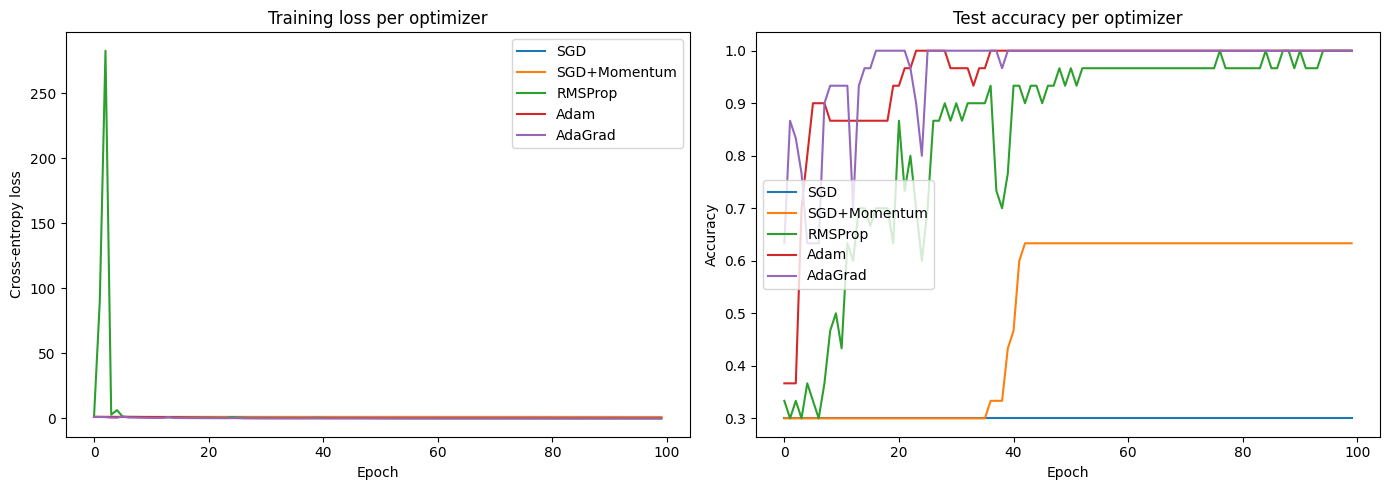


Optimizer          Final Loss   Test Acc
----------------------------------------
SGD                    1.0961     30.0%
SGD+Momentum           0.9948     63.3%
RMSProp                0.0381    100.0%
Adam                   0.0016    100.0%
AdaGrad                0.0271    100.0%


In [4]:
import torch, torch.nn as nn, torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Data ──────────────────────────────────────────────────────────────────────
df  = pd.read_csv(csv_path)
X   = StandardScaler().fit_transform(df.drop(["Id","Species"], axis=1).values)
y   = LabelEncoder().fit_transform(df["Species"].values)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_te = torch.tensor(y_te, dtype=torch.long)

# ── Model factory ─────────────────────────────────────────────────────────────
# Fresh model per optimizer — essential for a fair comparison.
# If all optimizers shared one model, the second optimizer would start from
# weights already tuned by the first.
def make_model():
    sizes = [4, 128, 128, 128, 128, 128, 128]
    layers = []
    for i in range(len(sizes)-1):
        layers += [nn.Linear(sizes[i], sizes[i+1]), nn.ReLU()]  # ReLU, not Sigmoid
    layers.append(nn.Linear(128, 3))
    return nn.Sequential(*layers)

# ── Optimizers under comparison ───────────────────────────────────────────────
# Each entry: (display name, optimizer class, kwargs)
# Adding a new optimizer = one new line here, nothing else changes.
OPTIMIZERS = [
    ("SGD",         optim.SGD,     {"lr": 0.01}),
    ("SGD+Momentum",optim.SGD,     {"lr": 0.01, "momentum": 0.9}),
    # RMSProp: adapts lr per-parameter using a running mean of squared gradients
    # good for non-stationary problems; precursor to Adam
    ("RMSProp",     optim.RMSprop, {"lr": 0.01}),
    # Adam: momentum + RMSProp combined + bias correction
    # m̂ = smoothed gradient,  v̂ = smoothed squared gradient
    # update = lr * m̂ / (√v̂ + ε)  — large historical gradients → smaller steps
    ("Adam",        optim.Adam,    {"lr": 0.001}),
    # AdaGrad: accumulates ALL past squared gradients (never forgets)
    # learning rate decays monotonically → eventually stops learning
    ("AdaGrad",     optim.Adagrad, {"lr": 0.01}),
]

# ── Train one model with one optimizer, return loss + accuracy curves ─────────
def train(opt_class, opt_kwargs, epochs=100):
    model = make_model()
    opt   = opt_class(model.parameters(), **opt_kwargs)
    crit  = nn.CrossEntropyLoss()
    losses, accs = [], []

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out  = model(X_tr)
        loss = crit(out, y_tr)
        loss.backward()
        opt.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            preds = model(X_te).argmax(dim=1)
            accs.append((preds == y_te).float().mean().item())

    return losses, accs

# ── Run all optimizers ────────────────────────────────────────────────────────
results = {name: train(cls, kw) for name, cls, kw in OPTIMIZERS}

# ── Plot: loss + accuracy side by side ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, (losses, accs) in results.items():
    ax1.plot(losses, label=name)
    ax2.plot(accs,   label=name)

ax1.set_title("Training loss per optimizer");  ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
ax2.set_title("Test accuracy per optimizer");  ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax1.legend(); ax2.legend()
plt.tight_layout(); plt.show()

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\n{'Optimizer':<16} {'Final Loss':>12} {'Test Acc':>10}")
print("-" * 40)
for name, (losses, accs) in results.items():
    print(f"{name:<16} {losses[-1]:>12.4f} {accs[-1]:>9.1%}")

filters

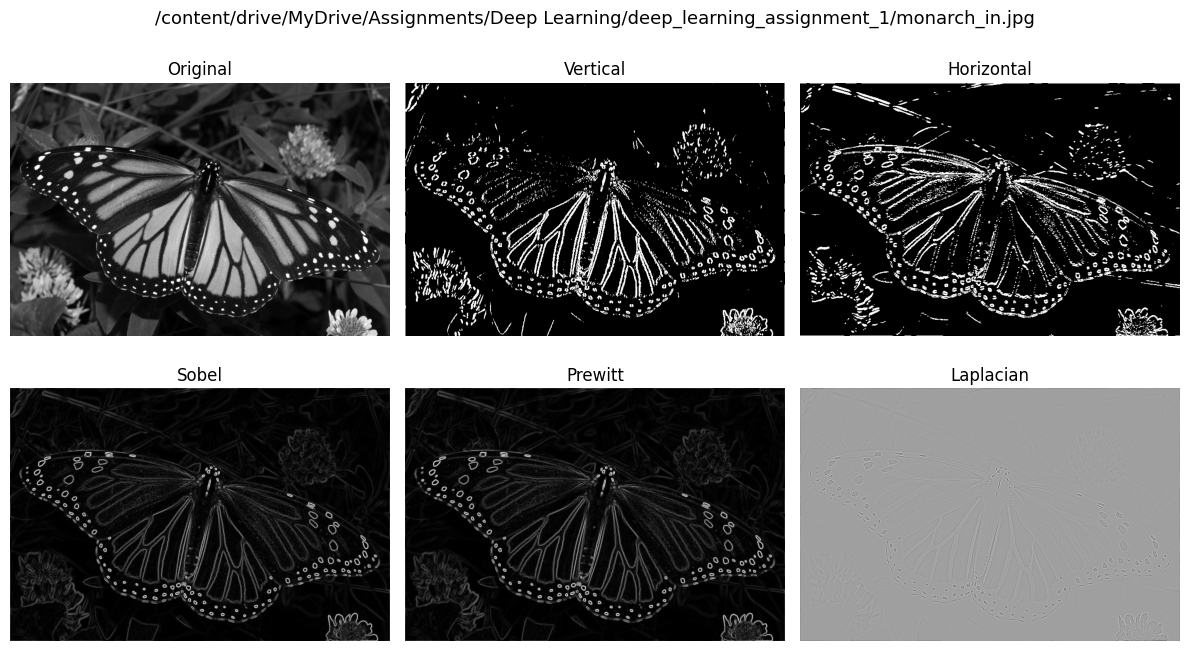

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ── Convolution ───────────────────────────────────────────────────────────────
# Slides kernel over every pixel. At each spot: multiply overlapping values,
# sum to one number → that becomes the new pixel. Same-padding keeps output
# size identical to input.
def convolve(img, K):
    ph, pw = K.shape[0]//2, K.shape[1]//2
    p = np.pad(img, ((ph,ph),(pw,pw)))
    return np.array([[np.sum(p[i:i+K.shape[0], j:j+K.shape[1]] * K)
                      for j in range(img.shape[1])] for i in range(img.shape[0])])

# ── Normalise ─────────────────────────────────────────────────────────────────
# Shifts output to [0,1] so all filters are visually comparable regardless of
# their raw magnitude (Laplacian produces negatives; Roberts produces tiny values)
norm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8)

# ── Kernels & names ───────────────────────────────────────────────────────────
# Each kernel is a small matrix of weights. The pattern of +1/-1 determines
# WHAT the filter responds to (edges, directions, curvature).
def gradient(img, Kx, Ky):
    # Two kernels → two directional responses → combine as vector magnitude
    # √(Gx²+Gy²) gives edge strength regardless of orientation
    return norm(np.sqrt(convolve(img,Kx)**2 + convolve(img,Ky)**2))

filters = {
    # Vertical only: one half of Prewitt (Kx alone) → responds ONLY to
    # vertical lines; horizontal edges produce zero response
    "Vertical": lambda i: (norm(np.abs(convolve(i,
                np.array([[-1,0,1],[-1,0,1],[-1,0,1]])))) > 0.1).astype(float),

    "Horizontal": lambda i: (norm(np.abs(convolve(i,
                np.array([[-1,-1,-1],[0,0,0],[1,1,1]])))) > 0.1).astype(float),

    # Sobel: centre row/col weighted ×2 → mild blur before differencing
    # makes it less noisy than Prewitt
    "Sobel":    lambda i: gradient(i,
                    np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
                    np.array([[-1,-2,-1],[0,0,0],[1,2,1]])),

    # Prewitt: uniform weights, no smoothing → sharper but noisier than Sobel
    "Prewitt":  lambda i: gradient(i,
                    np.array([[-1,0,1],[-1,0,1],[-1,0,1]]),
                    np.array([[-1,-1,-1],[0,0,0],[1,1,1]])),

    # Laplacian: 2nd derivative → finds WHERE brightness slope changes direction
    # responds to ALL edge orientations at once; no Gy needed
    # -4 centre + 4 neighbours: if pixel == neighbours → output 0 (flat region)
    "Laplacian":lambda i: norm(convolve(i,
                    np.array([[0,1,0],[1,-4,1],[0,1,0]]))),


}

# ── Run ───────────────────────────────────────────────────────────────────────
path = img_path
img  = cv2.imread(path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0   # float [0,1]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

axes[0].imshow(gray, cmap='gray'); axes[0].set_title("Original")
for ax, (name, fn) in zip(axes[1:], filters.items()):
    ax.imshow(fn(gray), cmap='gray'); ax.set_title(name)

for ax in axes: ax.axis('off')
plt.suptitle(path.split("\\")[-1], fontsize=13)
plt.tight_layout(); plt.show()